# <font color="ff6f00"> The Impact of 9/11 on Film Review Sentiment </font>

Khan Mamatov <br>
ECO 590 <br>
Spring 2026

### <font color="ff6f00"> Research Question </font>
1) Did 9/11 overall affect people's sentiment about earlier-released movies and, thus, their reviewing behavior?
2) Was the impact pronounced differently across genres?


 ### <font color="ff6f00"> Data Collection </font> 
I web-scraped film reviews from IMDb and used Vader Sentiment Analysis to analyze them and calculate the compound sentiment scores for each. 

### <font color="ff6f00"> Research Method  </font>

I conduct time-series analysis by month to identify whether 9/11 had an immediate and/or lasting impact on the people's review sentiment, using interrupted time series. I also seek to determine whether 9/11's impact varied across film genres - Romantic Comedy, Fantasy/Sci-Fi, Horror, War, Crime Thriller - which I have represented with popular films in my personally created IMDb lists.


### <font color="ff6f00"> Motivation </font>

The goal of this research is to determine whether a major political event can affect people's behavior towards and perceptions of media and entertainment, to examine whether politics can influence media consumption habits and spill over into entertainment, and to explore the concept of sensitization.

### <font color="ff6f00"> Dataset </font>

http://localhost:8888/edit/time_series_data.csv

In [944]:
# loads the necessary packages
import requests
import pandas as pd
import numpy as np
import pprint
# For graphing
import matplotlib.pyplot as plt 
import seaborn as sns

from boxoffice_api import BoxOffice # Box Office API package
from fredapi import Fred # FRED API package

from datetime import date # for datetime formats
import time # allows to add delays

import os # interacts with my operating system
from selenium import webdriver # launches and controls the browser
from selenium.webdriver.common.by import By # allows to specify how to find elements
from selenium.webdriver.chrome.service import Service # connects Selenium to my Chrome browser
from selenium.webdriver.support import expected_conditions as EC # allows to wait
from selenium.webdriver.support.ui import WebDriverWait # allows to pause
from selenium.webdriver.chrome.options import Options # allows to change aspects of the browser
from selenium.common.exceptions import NoSuchElementException # allows to see the error
import undetected_chromedriver as uc # so that IMDb doesn't block me from scraping

In [1137]:
chrome_options = Options() # specifies the options
chrome_options.add_argument("--window-size=1900,1000") # opens window with a width of 1900 pixels and a height of 1000 pixels
driver = webdriver.Chrome(options = chrome_options) # Selenium initializes the driver with the set options

Since April 2026, IMDb asks users to log in before showing reviews.

In [1138]:
sign_in_url = "https://www.imdb.com/registration/signin/" # the default sign-in page on IMDb
driver.get(sign_in_url) 

# The default value is 0 seconds, meaning Selenium will immediately throw an error if an element isn't found instantly
driver.implicitly_wait(10) 

# Finds and clicks on the button of signing in to an existing account
exist_account = driver.find_element(By.XPATH, "/html/body/div[2]/main/div/div/section/div/section/div/div/section/div/div[1]/div[2]/div[1]/button/span")
driver.execute_script("arguments[0].click();", exist_account) # because so many buttons on IMDb are embedded, we use 'execute.script(),' not 'click()'

# Finds and clicks on the button for an IMDb account
imdb_sign_in  = driver.find_element(By.XPATH, "/html/body/div[2]/main/div/div/section/div/section/div/div/section/div/div[1]/div[2]/div[1]/div[1]/a/span")
driver.execute_script("arguments[0].click();", imdb_sign_in) # clicks the button

email_input = driver.find_element(By.ID, "ap_email") # finds where to input the email
email_input.send_keys("amirhanmamatov@gmail.com") # types my email

password_input = driver.find_element(By.ID, "ap_password") # find where to input the password
password_input.send_keys("Saktyvari26") # types my password

sign_in_button = driver.find_element(By.ID, "signInSubmit") # finds the button by ID: #<input id="signInSubmit"
driver.execute_script("arguments[0].click();", sign_in_button) 

print('Done!')

Done!


In [1139]:
end_year = 2012 # set the end_year for our analysis

In [1140]:
# The lists on IMDb pre-made by me, each having 30 movies
fantasy_list = 'https://www.imdb.com/list/ls4176628884/?ref_=uspf_t_1' 
horror_list = 'https://www.imdb.com/list/ls4176676911/?ref_=uspf_t_2'
romcom_list = 'https://www.imdb.com/list/ls4176392604/?ref_=uspf_t_3'
crime_list = 'https://www.imdb.com/list/ls4176610082/?ref_=uspf_t_4'
war_list = 'https://www.imdb.com/list/ls4173176957/?ref_=uspf_t_5'

genre_dict = {'Fantasy/Sci-Fi' : fantasy_list, # genre_name : genre_list (which is URL)
               'Crime Thriller' : crime_list,
               'War' : war_list, 
               'Horror' : horror_list,
               'Romcom' : romcom_list}

First, we will write down the movies' IDs, titles, and genres, so that we can scrape the reviews by the movie IDs later, additionally grabbing their ratings.

In [1141]:
all_genre_data = [] # 

driver.implicitly_wait(0) # doesn't add any automatic delays, I have full control of the time

for genre_name, genre_list in genre_dict.items(): # loops through every 30-title-list of movies in our genre dictionary
    driver.get(genre_list) # tells Selenium to go to each genre list's URL
    
    titles = [] # list for movies titles
    ids = [] # list for movie IDs on IMDb, e.g., tt0075686 for Annie Hall
    genres = [] # list for 'genre_names' which will be replicated with every movie
    
    buckets = driver.find_elements(By.XPATH, "//li[contains(@class, 'ipc-metadata-list-summary-item')]") # searches for the list
    # "@"  - refers to an attribute, "class" - searches for the class attribute
    
    count = 1 # initiates the count

    for bucket in buckets: # we look into each movie's rectangle overview 
        
        title_element = bucket.find_element(By.XPATH, ".//h3") # getting the titles
        clean_title = title_element.text.split(". ", 1)[1]  # splits the title by a dot
        # Same thing, but we seek the movie IDs for each movie so as to go to the review pages later
        id_path = f"(//a[contains(@href, '/title/tt')])[{count}]" # finds all links that contain the string and loops with each count
        id_element = bucket.find_element(By.XPATH, id_path).get_attribute('href').split('/')[4] # splits the movie's ID by "/", gets the 5th item
        # .get_attribute() retrieves the value of an HTML attribute from a web element to get "tt0075686"
        # EX: <a href="https://www.imdb.com/title/tt0075686/?ref_=adv_li_tt">Annie Hall</a>
        
        titles.append(clean_title) # appends each title to the titles list
        ids.append(id_element) # appends each ID to the IDs list
        genres.append(genre_name) # we append 'genre_name' ('genre_dict' key) 30 times for each genre list
    
        count += 1 # add the increment at the end of the loop, turning to the next movie down the list
    
    ids_df = pd.DataFrame(ids) # creates a separate IDs dataframe
    titles_df = pd.DataFrame(titles) # creates a separate movie titles dataframe
    genres_df = pd.DataFrame(genres) # creates a separate genre names dataframe 

    genre_df = pd.concat([ids_df, titles_df, genres_df], axis=1) # horizontally concats all above into one for each genre 
    genre_df.columns = 'Movie ID', 'Title', 'Genre' # set the corresponding column names

    all_genre_data.append(genre_df) # appends each genre dataframe to a list of dataframes
    print('Done!') # we check the moment that Selenium has processed a list and how quickly

    time.sleep(3) # lets Selenium pause before turning to the next list, otherwise it skips 5 films from one of the lists and output 145 films

info_df = pd.concat(all_genre_data, ignore_index = True) # creates one whole dataframe, "ignore_index = True" assigns a new index order

print('Complete!')

Done!
Done!
Done!
Done!
Done!
Complete!


In [1142]:
info_df # our movies overview dataframe

,Movie ID,Title,Genre
0,tt0062622,2001: A Space Odyssey,Fantasy/Sci-Fi
1,tt0062622,The Abyss,Fantasy/Sci-Fi
2,tt0096754,Back to the Future,Fantasy/Sci-Fi
3,tt0096754,Beetlejuice,Fantasy/Sci-Fi
4,tt0088763,Blade Runner,Fantasy/Sci-Fi
...,...,...,...
145,tt0025316,Tootsie,Romcom
146,tt0116695,When Harry Met Sally...,Romcom
147,tt0116695,You've Got Mail,Romcom
148,tt0100405,The Wedding Singer,Romcom


Each genre should have 30 movies. If not - we'd have to redo the loop, possibly restarting the driver! Sometimes all 150 movies load, other times only 145, because one genre lags randomly.

In [987]:
# Let's quickly examine our movies for analysis: 

print('Fantasy/Sci-Fi:', len(info_df[info_df['Genre'] == 'Fantasy/Sci-Fi']) == 30)
print('Crime Thriller:', len(info_df[info_df['Genre'] == 'Crime Thriller']) == 30)
print('War:', len(info_df[info_df['Genre'] == 'War']) == 30)
print('Horror:', len( info_df[info_df['Genre'] == 'Horror']) == 30)
print('Romcom:', len( info_df[info_df['Genre'] == 'Romcom']) == 30)

Fantasy/Sci-Fi: True
Crime Thriller: True
War: True
Horror: True
Romcom: True


### Scraping Reviews

Now, we tell Selenium to use the movie IDs we've just established and examine each "Reviews" page, sorted in ascending order by review submission date. Selenium then clicks on the "Load More" button until it notices the last review for a given year, here 2012, and stops loading reviews (It seeks the review year inside the review bucket). Finally, before reading and extracting all the reviews, Selenium makes sure to click the spoiler button to see the full text for any review it can't diagnose. This way, we don't lose a big portion of information. While reading reviews, it checks again that it hasn't exceeded our final year of analysis.

Scraping 150 movies at once takes more than an hour. 

Also, apologies for some output printed - I wanted to know the scraping process was successful.

In [988]:
data = [] # a list first to put a dictionary later, from which we'll create a big dataframe

for movie_id, movie_title, movie_genre in zip(info_df['Movie ID'],
                                              info_df['Title'],
                                              info_df['Genre']): # the earlier created IDs to capture ALL the movies
    driver.get(f"https://www.imdb.com/title/{movie_id}/reviews/?sort=submission_date%2Casc&dir=asc") # uses the link for every movie_id 

    time.sleep(2) # lets Selenium sleep so that the page can fully load before Selenium starts looking for the 'See All' button
    count = 1 # initializes the count to loop through every review article
    
    # Step 1: Loading all reviews up to 'end_year', so there'd be no more need to click on 'See All'
    while True:
        see_all_button = driver.find_element(By.CSS_SELECTOR, ".ipc-see-more__button") # in this case, CSS selector is more effective than XPATHs
        driver.execute_script("arguments[0].click();", see_all_button) # simple '.click()' doesn't work because the button is embedded

       # Keeps checking every second — as long as the current article count equals the old count, it keeps waiting
        all_reviews = driver.find_elements(By.XPATH, "//article") # searches for all reveiw articles to check
        last_date = all_reviews[-1].find_element(By.XPATH, ".//div[2]/ul/li[2]").text # finds the last review's date
        last_year = int(last_date.split()[-1].strip()) # splits all elements, extracts the last one, and gives only the number

        if last_year > end_year: # if Selenium notices the very last review on our page exceeds that of our pre-defined year, it stops clicking the button 
            break # stops
            
    for spoiler_button in driver.find_elements(By.XPATH, "//button[contains(., 'Spoiler')]"): # Clicks all spoiler buttons before scraping 
    # '//' - searches the entire page, 'button' - searches for the button HTML, '.' - searches for this element's text content
        driver.execute_script("arguments[0].click();", spoiler_button) # clicks
        
    # Step 2: Scraping all loaded reviews up to the end year - 2012
    while True:
        review = driver.find_element(By.XPATH, f"//article[{count}]") # searches for "article" html element
        review_date = review.find_element(By.XPATH, ".//div[2]/ul/li[2]").text # searches for the container
        year = int(review_date.split()[-1].strip()) # splits and strips  newlines, gives the last element
        month = review_date.split()[0].strip() # splits and strips newlines, gives the first element

        if year > end_year: # if Selenium notices a review's movie exceeds that of our pre-defined year, I tell it not to write it down
            print(f"Reached {year} for {movie_title}, scraping next.") # So that Selenium always reaches the end year
            break # stops

        # To get the review texts, get_attribute retrieves an HTML element, while "textContent" returns all the text inside an element
        review_text = review.find_element(By.CSS_SELECTOR, ".ipc-html-content-inner-div").get_attribute("textContent").strip()
        
        # Using a dictionary, appends to the 'data' list:
        data.append({'Title': movie_title, 'Genre': movie_genre, # title and genre alredy defined in the 'info_df'
                     'Date': review_date, # newly found review date
                     'Month, Year': f"{month}, {year}", # from review date, exctracts month+year combination
                     'Review': review_text}) # newly found review's inner text itself
        count += 1 # adds the increment at the end
        
print("Done!")

Reached 2013 for 2001: A Space Odyssey, scraping next.
Reached 2013 for The Abyss, scraping next.
Reached 2013 for Back to the Future, scraping next.
Reached 2013 for Beetlejuice, scraping next.
Reached 2013 for Blade Runner, scraping next.
Reached 2013 for Close Encounters of the Third Kind, scraping next.
Reached 2013 for Conan the Barbarian, scraping next.
Reached 2013 for Dune, scraping next.
Reached 2013 for Edward Scissorhands, scraping next.
Reached 2013 for E.T. the Extra-Terrestrial, scraping next.
Reached 2013 for The Fifth Element, scraping next.
Reached 2013 for Highlander, scraping next.
Reached 2013 for Hook, scraping next.
Reached 2013 for Jumanji, scraping next.
Reached 2013 for Jurassic Park, scraping next.
Reached 2013 for Labyrinth, scraping next.
Reached 2013 for Matilda, scraping next.
Reached 2013 for Men in Black, scraping next.
Reached 2013 for Starship Troopers, scraping next.
Reached 2013 for Star Trek: First Contact, scraping next.
Reached 2013 for Star Wars:

In [1218]:
data_df = pd.DataFrame(data) # Creates the big review dataframe we are going to clean

In [1219]:
# How many reviews does each movie have? 

total_reviews = 0 
total_movies = 1
review_numbers = [] # creates a list for histogram
for movie in data_df['Title'].unique(): # looping through every unique instance of movies
    total_movies += 1
    review_number = len(data_df[data_df['Title'] == movie]) # calculates the number of reviews for each movie 
    review_numbers.append(review_number) # appends total number of reviews for each movie
    #print(f'{movie} has {review_number} reviews.') - prints how many reviews each one has
    total_reviews += review_number # adds single totals to the grand total
print(f'There is {total_movies} movies.') 

# Ideally, all 150 movies should be processed.

There is 150 movies.


In [1220]:
print(f"There is a total of {total_reviews} reviews.") # to double-check the total number of reviews

There is a total of 65328 reviews.


Let's plot the distribution of the review counts.

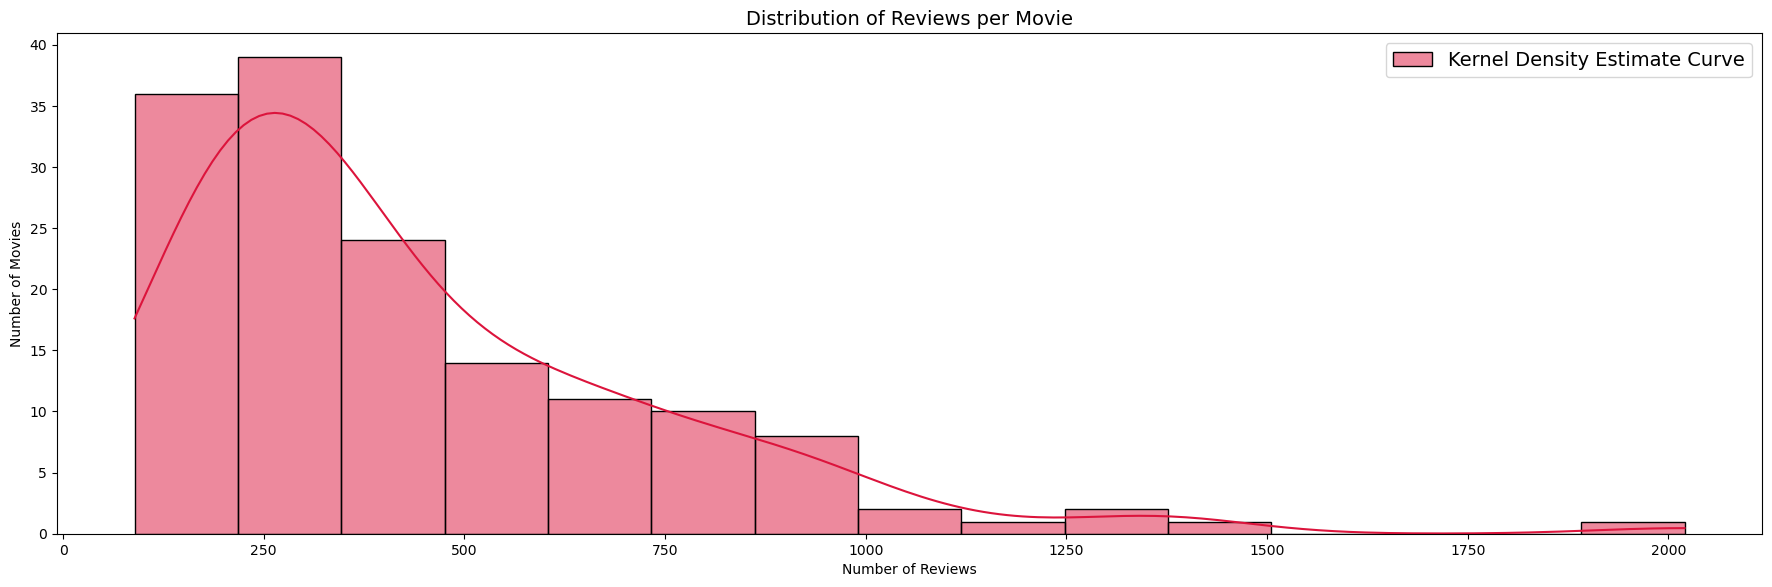

In [1221]:
plt.figure(figsize = (22, 6.5)) # I want it to take less space, so I set it to be wider

sns.histplot(review_numbers, bins = 15,
             kde = True, color = 'crimson', label = 'Kernel Density Estimate Curve') # 'kde' adds Kernel Density Estimate

plt.title('Distribution of Reviews per Movie', fontsize = 14) # plot title
plt.xlabel('Number of Reviews') # x-axis label
plt.ylabel('Number of Movies') # y-axis label
plt.legend(fontsize = 14, loc = 'best') # finds the best place for the legend

plt.show() # outputs the plot

The distribution is not very uniform, it is handy that we average them by genre.

#### Now, let's analyze reviews and assign the sentiment scores using Vader Sentiment Analysis

Source of Vader Sentiment Analysis — https://www.geeksforgeeks.org/python/python-sentiment-analysis-using-vader/



In [1222]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer # imports the package 
import nltk

def sentiment_scores(sentence):
    sid_obj = SentimentIntensityAnalyzer()
    sentiment_dict = sid_obj.polarity_scores(sentence)
    
    return sentiment_dict # So, I made the function return the sentiment dictionary, so that I could extract the key named 'compound'

# EXAMPLE
sentiment_scores('It gives a million reason why no one should go.') 

{'neg': 0.216, 'neu': 0.784, 'pos': 0.0, 'compound': -0.296}

We'll use the *'compound'* sentiment score as a single sentiment metric of a review. 

In [1223]:
# Let's create a list of the "compound" sentiment scores
sentiment_score = [sentiment_scores(review)['compound'] for review in data_df['Review']] # list comprehension for a every text value of the data_df
data_df['Single Sentiment Score'] = sentiment_score # turns the sentiment list into a new column

print('Done!') 

Done!


In [1231]:
data_df['date'] = pd.to_datetime(data_df['Month, Year'], format = '%b, %Y') # converts the month+year column to datetime, right now format doesn't matter to pandas

# Additionally, we created a new date-format column 'date', which we will use in later analysis
data_df = data_df.sort_values('date') # sorts by review date
data_df = data_df.reset_index(drop = True) # importantly, resets the index

data_df

,Title,Genre,Date,"Month, Year",Review,Single Sentiment Score,date
0,2001: A Space Odyssey,Fantasy/Sci-Fi,"Jul 30, 1998","Jul, 1998",2001 is probably the most technically perfect ...,0.8397,1998-07-01
1,Saving Private Ryan,War,"Jul 30, 1998","Jul, 1998",The writing and the story were weak at times. ...,0.2617,1998-07-01
2,L.A. Confidential,Crime Thriller,"Jul 31, 1998","Jul, 1998",The movie was excellent. It was very well don...,0.7498,1998-07-01
3,Star Wars: Episode IV - A New Hope,Fantasy/Sci-Fi,"Jul 29, 1998","Jul, 1998",One of my all time favorite movies comes with ...,0.5719,1998-07-01
4,Saving Private Ryan,War,"Jul 30, 1998","Jul, 1998","Although I hate to argue, I can't say this was...",0.7314,1998-07-01
...,...,...,...,...,...,...,...
65323,The Last of the Mohicans,War,"Dec 8, 2012","Dec, 2012",I saw this in a theater when it was first rele...,0.9907,2012-12-01
65324,Point Break,Crime Thriller,"Dec 15, 2012","Dec, 2012",Effective is the adjective that perhaps descri...,0.7167,2012-12-01
65325,The Silence of the Lambs,Horror,"Dec 3, 2012","Dec, 2012",I'm definitely a fan of horror films and films...,0.9980,2012-12-01
65326,North by Northwest,Crime Thriller,"Dec 23, 2012","Dec, 2012",What makes this movie stand apart from the mod...,0.9246,2012-12-01


#### Now, as we've sorted our dataframe by month, let's calculate the mean compound score for every month and genre.

In [1366]:
grouped_data_df = data_df.groupby(['date', 'Genre'])['Single Sentiment Score'].mean().reset_index()
grouped_data_df

,date,Genre,Single Sentiment Score
0,1998-07-01,Crime Thriller,0.344967
1,1998-07-01,Fantasy/Sci-Fi,0.798360
2,1998-07-01,Horror,0.641500
3,1998-07-01,Romcom,0.797482
4,1998-07-01,War,0.237822
...,...,...,...
865,2012-12-01,Crime Thriller,0.609252
866,2012-12-01,Fantasy/Sci-Fi,0.727287
867,2012-12-01,Horror,0.161439
868,2012-12-01,Romcom,0.840948


In [1227]:
(6 + 12 * 14) * 5
# 6 months (left in 1998) + 14 more years * 12 months) = 174 months in total
# 174 months * 5 genres = 870 observations

870

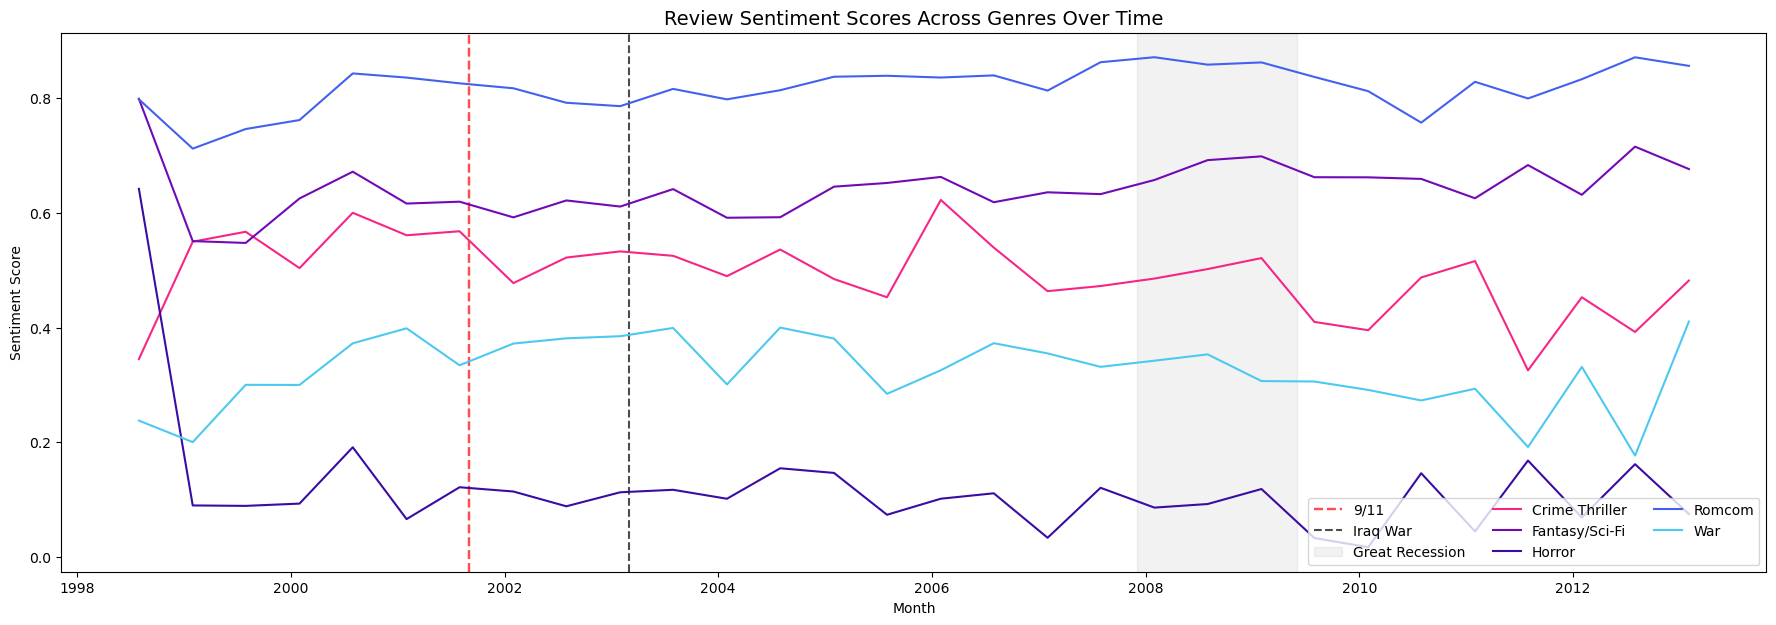

In [1229]:
plt.figure(figsize = (22, 7))

# 174 is divisible by 6, so it allowed me to resample the months into every 6 to smooth the volatility and see the OVERALL trend
plot_data = grouped_data_df.groupby('Genre').resample('6ME', on = 'date')['Single Sentiment Score'].mean().reset_index() # specific plot data
colors = ["#F72585", "#7209B7", "#3A0CA3", "#4361EE", "#4CC9F0"] # my own palette using colors from the Web

plt.axvline(x = pd.to_datetime('2001-09-01'), # converts the September 2001 into a datetime object to correctly place the line on the axis
            color = 'red', linestyle = '--', linewidth = 1.75, alpha = 0.7, # alpha - regulates the opacity 
            label = '9/11') # the label for the legend

plt.axvline(x = pd.to_datetime('2003-03-01'), # converts the September 2001 into a datetime object to correctly place the line on the axis
            color = 'black', linestyle = '--', linewidth = 1.5, alpha = 0.7, # alpha - regulates the opacity 
            label = 'Iraq War') # the label for the legend

plt.axvspan('2007-12-01', '2009-06-01', color = 'gray', alpha = 0.10, label = 'Great Recession') # Recession shading

sns.lineplot(data = plot_data, # uses the newly created dataframe resampled for 6 months
             x = 'date', # dates are to be displayed on the x-axis
             y = 'Single Sentiment Score', # scores are to be displayed on the y-axis
             hue = 'Genre', # groups by genre and gives different colors
             palette = colors) # using my pre-defined colors

plt.title('Review Sentiment Scores Across Genres Over Time', fontsize = 14) # plot title
plt.xlabel('Month') # x-axis label
plt.ylabel('Sentiment Score') # y-axis label
plt.legend(fontsize = 10, loc = 'lower right', ncol = 3) # finds the best place for the legend, organizes it in 2 columns

# saving the plot
plt.savefig('reviewsentiments.png')

plt.show() # outputs the plot

Now, we'll give each genre its own column by creating a pivot table and transforming it into a dataframe.

In [1232]:
data_pivot = grouped_data_df.pivot(index = 'date', # date becomes our horizontal pivot column
                                   columns = 'Genre', # genres become our groups 
                                   values = 'Single Sentiment Score') # values go inside the pivot
data_pivot.columns.name = None # helps me turn the pivot into a normal-looking pivot, making the date index its own column

In [1233]:
data_pivot_df = data_pivot.reset_index() # adds the index and turns the pivot into a separate dataframe

Let's calculate the overall average score across all genres.

In [1234]:
data_pivot_df['Overall'] = data_pivot_df[['Crime Thriller', # creates a new column
                                          'Fantasy/Sci-Fi',
                                          'Horror',
                                          'Romcom',
                                          'War']].mean(axis = 1) # takes a mean of the genres across all rows, since axis = 1 refers to columns
data_pivot_df

,date,Crime Thriller,Fantasy/Sci-Fi,Horror,Romcom,War,Overall
0,1998-07-01,0.344967,0.798360,0.641500,0.797482,0.237822,0.564026
1,1998-08-01,0.647088,0.575106,-0.024716,0.704674,0.113489,0.403128
2,1998-09-01,0.556528,0.569964,0.058896,0.679907,0.218633,0.416786
3,1998-10-01,0.485180,0.556775,0.005405,0.719048,0.283291,0.409940
4,1998-11-01,0.564890,0.669245,0.184848,0.652414,0.196182,0.453516
...,...,...,...,...,...,...,...
169,2012-08-01,0.579388,0.777121,0.067476,0.766636,0.483531,0.534830
170,2012-09-01,0.324702,0.614681,-0.028526,0.786440,0.489475,0.437355
171,2012-10-01,0.593422,0.684200,0.073558,0.959444,0.592528,0.580630
172,2012-11-01,0.302100,0.576313,0.101517,0.924958,0.410578,0.463093


### Let's Create a Few New Variables
First, we will extract the top-ranked movies for each month by their total box office. The scope is between the years 1998 and 2012. <br>
We use the box office API library. <br>
Link to the API documentation: https://pypi.org/project/boxoffice-api.

In [1235]:
box_office = BoxOffice(outputformat = "DF") # outputs to a dataframe according to the documentation, which is easier to process
monthly_data = [] # we set a list to append each month's top-ranked movies so that the output dataframe is in chronological order

for year in range(1998, end_year + 1): # from 1998 to 2013, not including 2013
    for month in range(1, 13): # not including 13, so each month
        monthly_tops = box_office.get_monthly(year = year, month = month) # monthly tops is a dataframe; ultimately we result in many 
        # We set both the year and month columns to each dataframe, just to be sure and aware of the date order
        monthly_tops['Year'] = year # this is the current year of the ranking, a column
        monthly_tops['Month'] = month # this is the current month of the ranking, a column
        
        monthly_data.append(monthly_tops) # appending 'monthly_tops' one by one, starting from the earliest date, Jan 1998

monthly_data_df = pd.concat(monthly_data, axis = 0).reset_index(drop = True) # stacking many dataframes, axis = 0 means by each row

print('Done!')

Done!


In [1236]:
monthly_data_df

,Rank,Release,Gross,Theaters,Total Gross,Release Date,Distributor,Year,Month
0,1,Titanic,"$188,215,666","3,265","$600,683,057",Dec 19,Paramount Pictures,1998,1
1,2,As Good as It Gets,"$59,523,768","1,837","$148,478,011",Dec 23,Sony Pictures Releasing,1998,1
2,3,Good Will Hunting,"$49,409,331","2,203","$138,433,435",Dec 5,Miramax,1998,1
3,4,Tomorrow Never Dies,"$42,773,740","2,807","$125,304,276",Dec 19,Metro-Goldwyn-Mayer (MGM),1998,1
4,5,Mousehunt,"$27,515,643","2,233","$61,917,389",Dec 19,DreamWorks Distribution,1998,1
...,...,...,...,...,...,...,...,...,...
28248,170,Nothing But a Man,$272,2,"$13,063",Nov 9,Cinema Conservancy,2012,12
28249,171,Galapagos,$243,14,"$18,630,372",Oct 29,IMAX,2012,12
28250,172,Free Radicals: A History of Experimental Film,$214,1,"$3,804",Aug 3,Kino Lorber,2012,12
28251,173,A Man Vanishes2012 Re-release,$105,2,"$6,201",Nov 15,Icarus Films,2012,12


In [1237]:
# Creates a separate column for Month + Year, using strings
# Important to convert the year and month columns' values into strings for concatenation
monthly_data_df['Month, Year'] =  monthly_data_df['Year'].astype(str) + '-' + monthly_data_df['Month'].astype(str) + '-' + '01'

In [1238]:
# converts the newly created column into a proper datetime format
monthly_data_df['Month, Year'] = pd.to_datetime(monthly_data_df['Month, Year'], format = '%Y-%m-%d') # format: 1998-01-01

In [1239]:
target_movies = list(set(monthly_data_df['Release'])) # extracts all unique movie titles from the above df and converts into a "target" list
print(target_movies[:6]) # Prints some of our target movies

print("There is", len(target_movies), "target movies.") # Prints how many target movies we've got within our timeframe

['Freeriders', 'Carman: The Champion', 'Fireworks', 'Hairspray', 'Kill the Irishman', 'La Commune (Paris, 1871)']
There is 7551 target movies.


We look for movies, released between 1998 and 2013, which are in the top 100,000 popular films on IMDb: <br>
Here, our genres are slightly different: <br>
Instead of Crime Thriller, I examine Crime and Thriller genres separately. <br>
Instead of Fantasy/Sci-Fi, I examine Fantasy and Sci-Fi genres separately. <br>
I don't include Romance, since a lot of movies can be Romance, plus their performance is similar to that of Comedies. 

In [1049]:
# Assigns the URL links to each variable
crime_url = "https://www.imdb.com/search/title/?title_type=feature&release_date=1997-12-31,2012-12-31&genres=crime&countries=US&moviemeter=,100000"
thriller_url = "https://www.imdb.com/search/title/?title_type=feature&release_date=1997-12-31,2012-12-31&genres=thriller&countries=US&moviemeter=,100000"
fantasy_url = "https://www.imdb.com/search/title/?title_type=feature&release_date=1997-12-31,2012-12-31&genres=fantasy&countries=US&moviemeter=,100000"
scifi_url = "https://www.imdb.com/search/title/?title_type=feature&release_date=1997-12-31,2012-12-31&genres=sci-fi&moviemeter=,100000"
comedy_url = "https://www.imdb.com/search/title/?title_type=feature&release_date=1997-12-31,2012-12-31&genres=comedy&moviemeter=,100000"
horror_url = "https://www.imdb.com/search/title/?title_type=feature&release_date=1997-12-31,2012-12-31&genres=horror&moviemeter=,100000"
war_url = "https://www.imdb.com/search/title/?title_type=feature&release_date=1997-12-31,2012-12-31&genres=war&moviemeter=,100000"

urls = {'Crime': crime_url, # we use a dictionary, so that we can append the genres to our dataframe along the way
        'Thriller': thriller_url,
        'Fantasy' : fantasy_url,
        'Sci-Fi' : scifi_url,
        'Comedy' : comedy_url,
        'Horror' : horror_url,
        'War' : war_url
       }

In [552]:
chrome_options = Options() # specifies the options
chrome_options.add_argument("--window-size=1900,1000") # opens window with a width of 1900 pixels and a height of 1000 pixels
driver = webdriver.Chrome(options = chrome_options) # Selenium initializes the driver with the set options

In [572]:
top_movies = [] # here we will append all of our top movies

for genre, url in urls.items(): # for each key and value in our dictionary 
    driver.get(url) 
    
    time.sleep(3)
    
    while True: # First, we click on the "Load More" button until it's gone
        try:
            load_more_btn = driver.find_element(By.CSS_SELECTOR, ".ipc-see-more__button") # seekign by the CSS selector
            driver.execute_script("arguments[0].click();", load_more_btn) # It might not get clicked because it might be embedded
            time.sleep(3) # wait
            
        except NoSuchElementException: # The instance when the button is gone
            print("All Movies Are Loaded") # We make sure all movies are loaded, and the button is gone
            break
    
    movies_on_page = driver.find_elements(By.CLASS_NAME, "ipc-metadata-list-summary-item")
                                                                                           # splits on the first instance of the dot
    bucket_titles = [bucket.find_element(By.CSS_SELECTOR, ".ipc-title__text ").text.split(". ", 1)[1] for bucket in movies_on_page]
    # 'any' allows us to save the movie only once it finds the movie equates to on of our titles; it stops looking and moves to the next movie
    matches = [target_movie for target_movie in target_movies if any(target_movie == title for title in bucket_titles)]
    # appends the list with a target_movie if it is in our target list
    # we need '=' because before this I had a problem where another movie Titanic: The Legend Goes On (2000) would count for Titanic (1998)

    for movie in matches: # Then we loop through the matches to save them in a dictionary so that the genre for each one aligns
        top_movies.append({'Release': movie,
                           'Genre': genre})
print('Done!')

All Movies Are Loaded
All Movies Are Loaded
All Movies Are Loaded
All Movies Are Loaded
All Movies Are Loaded
All Movies Are Loaded
All Movies Are Loaded
Done!


A simple dataframe with a "target" movie and its genre:

In [1240]:
top_movies_df = pd.DataFrame(top_movies)
top_movies_df

,Release,Genre
0,Kill the Irishman,Crime
1,High Heels and Low Lifes,Crime
2,From Hell,Crime
3,Killer Elite,Crime
4,Paul Blart: Mall Cop,Crime
...,...,...
5234,Australia,War
5235,Redacted,War
5236,Eichmann,War
5237,Amigo,War


In [1241]:
len(top_movies_df) # There is a total of 5239 'target' movies

5239

In [1242]:
top_movies_df[top_movies_df[['Release','Genre']].duplicated()] # to double-check if there are any duplicates across both columns
# There is none

,Release,Genre


However, some movies are of multiple genres - we can leave them as they are:

In [1243]:
top_movies_df[top_movies_df['Release'].duplicated()].reset_index(drop = True)
# There are 1677 such movies

,Release,Genre
0,From Hell,Thriller
1,Killer Elite,Thriller
2,Fight Club,Thriller
3,Hard Rain,Thriller
4,Out of Time,Thriller
...,...,...
1672,Bon Voyage,War
1673,No Man's Land,War
1674,Jakob the Liar,War
1675,Legend of the Guardians: The Owls of Ga'Hoole,War


We'll check if the movie is in the top 100,000 popular films on IMDb. <br>
Basically, we are combining the API box office (monthly_data_df) and our recently web-scraped data (top_movies_df)

In [1354]:
top_monthly_data_df = monthly_data_df[monthly_data_df['Release'].isin(top_movies_df['Release'])] # we return a new dataframe
top_monthly_data_df = top_monthly_data_df.reset_index(drop = True) # resets the index, dropping the previous
top_monthly_data_df

,Rank,Release,Gross,Theaters,Total Gross,Release Date,Distributor,Year,Month,"Month, Year"
0,8,Fallen,"$19,553,109","2,448","$25,232,289",Jan 16,Warner Bros.,1998,1,1998-01-01
1,12,Hard Rain,"$14,860,215","2,132","$19,870,567",Jan 16,Paramount Pictures,1998,1,1998-01-01
2,14,Half Baked,"$12,969,520","1,703","$17,460,020",Jan 16,Universal Pictures,1998,1,1998-01-01
3,19,Firestorm,"$8,165,212","2,057","$8,165,212",Jan 9,20th Century Fox,1998,1,1998-01-01
4,26,Phantoms,"$3,963,395","1,859","$5,624,282",Jan 23,Miramax,1998,1,1998-01-01
...,...,...,...,...,...,...,...,...,...,...
12985,145,The Imposter,"$2,115",31,"$898,317",Jul 13,Indomina Releasing,2012,12,2012-12-01
12986,147,Chicken with Plums,"$1,925",24,"$253,874",Aug 17,Sony Pictures Classics,2012,12,2012-12-01
12987,149,The Day He Arrives,"$1,293",2,"$13,746",Apr 20,The Cinema Guild,2012,12,2012-12-01
12988,150,Celeste & Jesse Forever,"$1,242",586,"$3,094,813",Aug 3,Sony Pictures Classics,2012,12,2012-12-01


In order to assign the genres to our highest-grossing films, we'll perform the merge. Each films might get assigned to several genres.

In [1355]:
top_monthly_data_df = pd.merge(top_monthly_data_df, top_movies_df, on = 'Release', how = 'left') # joins on top_monthly_data
top_monthly_data_df

,Rank,Release,Gross,Theaters,Total Gross,Release Date,Distributor,Year,Month,"Month, Year",Genre
0,8,Fallen,"$19,553,109","2,448","$25,232,289",Jan 16,Warner Bros.,1998,1,1998-01-01,Crime
1,8,Fallen,"$19,553,109","2,448","$25,232,289",Jan 16,Warner Bros.,1998,1,1998-01-01,Thriller
2,8,Fallen,"$19,553,109","2,448","$25,232,289",Jan 16,Warner Bros.,1998,1,1998-01-01,Fantasy
3,12,Hard Rain,"$14,860,215","2,132","$19,870,567",Jan 16,Paramount Pictures,1998,1,1998-01-01,Crime
4,12,Hard Rain,"$14,860,215","2,132","$19,870,567",Jan 16,Paramount Pictures,1998,1,1998-01-01,Thriller
...,...,...,...,...,...,...,...,...,...,...,...
19110,145,The Imposter,"$2,115",31,"$898,317",Jul 13,Indomina Releasing,2012,12,2012-12-01,Thriller
19111,147,Chicken with Plums,"$1,925",24,"$253,874",Aug 17,Sony Pictures Classics,2012,12,2012-12-01,Comedy
19112,149,The Day He Arrives,"$1,293",2,"$13,746",Apr 20,The Cinema Guild,2012,12,2012-12-01,Comedy
19113,150,Celeste & Jesse Forever,"$1,242",586,"$3,094,813",Aug 3,Sony Pictures Classics,2012,12,2012-12-01,Comedy


In [1356]:
top_monthly_data_df.isna().sum() # checks for NaN values

Rank            0
Release         0
Gross           0
Theaters        0
Total Gross     0
Release Date    0
Distributor     0
Year            0
Month           0
Month, Year     0
Genre           0
dtype: int64

Let's count how many big releases there were in each month and each genre:

In [1357]:
counts_df = top_monthly_data_df.groupby(['Month, Year','Genre'])['Release'].count().reset_index() 
# aggregates by the number of genre instances for each month

In [1358]:
# Here is a slight problem

print('Crime', len(counts_df[counts_df['Genre'] == 'Crime']))
print('Thriller', len(counts_df[counts_df['Genre'] == 'Thriller']))
print('Comedy', len(counts_df[counts_df['Genre'] == 'Comedy']))
print('Fantasy', len(counts_df[counts_df['Genre'] == 'Fantasy']))
print('Sci-Fi', len(counts_df[counts_df['Genre'] == 'Sci-Fi']))
print('Horror', len(counts_df[counts_df['Genre'] == 'Horror']))
print('War', len(counts_df[counts_df['Genre'] == 'War']))
      
# Not all genre instances are the same over the years

Crime 180
Thriller 180
Comedy 180
Fantasy 180
Sci-Fi 180
Horror 178
War 174


In [1361]:
# Filters for months in the list, where the War genre is not present: ~ means NOT
counts_df[~counts_df['Month, Year'].isin(counts_df[counts_df['Genre'] == 'War']['Month, Year'].unique())]#.reset_index(drop=True)

,"Month, Year",Genre,Release
0,1998-01-01,Comedy,2
1,1998-01-01,Crime,5
2,1998-01-01,Fantasy,1
3,1998-01-01,Horror,2
4,1998-01-01,Sci-Fi,2
5,1998-01-01,Thriller,6
6,1998-02-01,Comedy,7
7,1998-02-01,Crime,9
8,1998-02-01,Fantasy,2
9,1998-02-01,Horror,3


In [1363]:
# Filters for months in the list, where the Horror genre is not present: : ~ means NOT
counts_df[~counts_df['Month, Year'].isin(counts_df[counts_df['Genre'] == 'Horror']['Month, Year'].unique())]#.reset_index(drop=True)

,"Month, Year",Genre,Release
24,1998-05-01,Comedy,16
25,1998-05-01,Crime,6
26,1998-05-01,Fantasy,4
27,1998-05-01,Sci-Fi,3
28,1998-05-01,Thriller,8
29,1998-06-01,Comedy,20
30,1998-06-01,Crime,3
31,1998-06-01,Fantasy,4
32,1998-06-01,Sci-Fi,4
33,1998-06-01,Thriller,7


So, now we will fill those missing rows with zeros for the corresponding years. Importantly, we convert the dates into a datetime format:

War is missing in 6 months:<br>
1998-01-01,<br>
1998-02-01,<br>
1998-03-01,<br>
1998-04-01,<br>
1998-05-01,<br>
2011-03-01.

Horror is missing in 3 months: <br>
1998-05-01, <br>
1998-06-01.

In [1285]:
counts_df.loc[1252] = [pd.to_datetime('1998-01-01'), 'War', 0] # Assigns '0' to War as specific months
counts_df.loc[1253] = [pd.to_datetime('1998-02-01'), 'War', 0] 
counts_df.loc[1254] = [pd.to_datetime('1998-03-01'), 'War', 0]
counts_df.loc[1255] = [pd.to_datetime('1998-04-01'), 'War', 0]
counts_df.loc[1256] = [pd.to_datetime('1998-05-01'), 'War', 0]
counts_df.loc[1257] = [pd.to_datetime('2011-03-01'), 'War', 0]

In [1286]:
counts_df.loc[1258] = [pd.to_datetime('1998-05-01'), 'Horror', 0] # Assigns '0' to Horror at specific months
counts_df.loc[1259] = [pd.to_datetime('1998-06-01'), 'Horror', 0]

In [1287]:
print('Crime', len(counts_df[counts_df['Genre'] == 'Crime']))
print('Thriller', len(counts_df[counts_df['Genre'] == 'Thriller']))
print('Comedy', len(counts_df[counts_df['Genre'] == 'Comedy']))
print('Fantasy', len(counts_df[counts_df['Genre'] == 'Fantasy']))
print('Sci-Fi', len(counts_df[counts_df['Genre'] == 'Sci-Fi']))
print('Horror', len(counts_df[counts_df['Genre'] == 'Horror']))
print('War', len(counts_df[counts_df['Genre'] == 'War']))
      
# All instances equal to 180

Crime 180
Thriller 180
Comedy 180
Fantasy 180
Sci-Fi 180
Horror 180
War 180


In [1288]:
counts_df # Now, there is 15 years * 12 months * 7 genres = 1260 observations - just as it should be

,"Month, Year",Genre,Release
0,1998-01-01,Comedy,2
1,1998-01-01,Crime,5
2,1998-01-01,Fantasy,1
3,1998-01-01,Horror,2
4,1998-01-01,Sci-Fi,2
...,...,...,...
1255,1998-04-01,War,0
1256,1998-05-01,War,0
1257,2011-03-01,War,0
1258,1998-05-01,Horror,0


#### Let's find the maximum rank for each month

In [1289]:
# Before that, once more convert the date column into a datetime format
counts_df['Month, Year'] = pd.to_datetime(counts_df['Month, Year'], format = '%Y-%m-%d')

In [1091]:
monthly_data_df['Rank'] = monthly_data_df['Rank'].astype(int) # to be sure, first we'll convert the rank values into integer numbers
max_ranks_df = monthly_data_df.groupby('Month, Year')['Rank'].max().reset_index() # finally, finds the maximum rank for each month

max_ranks_df

,"Month, Year",Rank
0,1998-01-01,45
1,1998-02-01,46
2,1998-03-01,54
3,1998-04-01,61
4,1998-05-01,54
...,...,...
175,2012-08-01,200
176,2012-09-01,200
177,2012-10-01,200
178,2012-11-01,200


In [1290]:
pop_df = counts_df.merge(max_ranks_df[['Month, Year', 'Rank']], # these are the columns to look for and match in the right table
                         on = 'Month, Year', # this is the column on which to perform a join
                         how = 'right' # unlike right join, inner join would return only matching values
                        )
pop_df

,"Month, Year",Genre,Release,Rank
0,1998-01-01,Comedy,2,45
1,1998-01-01,Crime,5,45
2,1998-01-01,Fantasy,1,45
3,1998-01-01,Horror,2,45
4,1998-01-01,Sci-Fi,2,45
...,...,...,...,...
1255,2012-12-01,Fantasy,11,174
1256,2012-12-01,Horror,10,174
1257,2012-12-01,Sci-Fi,7,174
1258,2012-12-01,Thriller,26,174


In [1291]:
print(top_monthly_data_df.isna().sum()) # checks by summming if there are any NaN value rows

Rank            0
Release         0
Gross           0
Theaters        0
Total Gross     0
Release Date    0
Distributor     0
Year            0
Month           0
Month, Year     0
Genre           0
dtype: int64


#### So, now we calculate the new variables: 
Again, <br>
Release - the count of the movies of each genre in a given month  <br>
Rank - the total number of movies in the box office top according to the Box Office API 

In [1293]:
pop_df['Proportion'] = pop_df['Release'] / pop_df['Rank'] # calculates and creates a brand new column

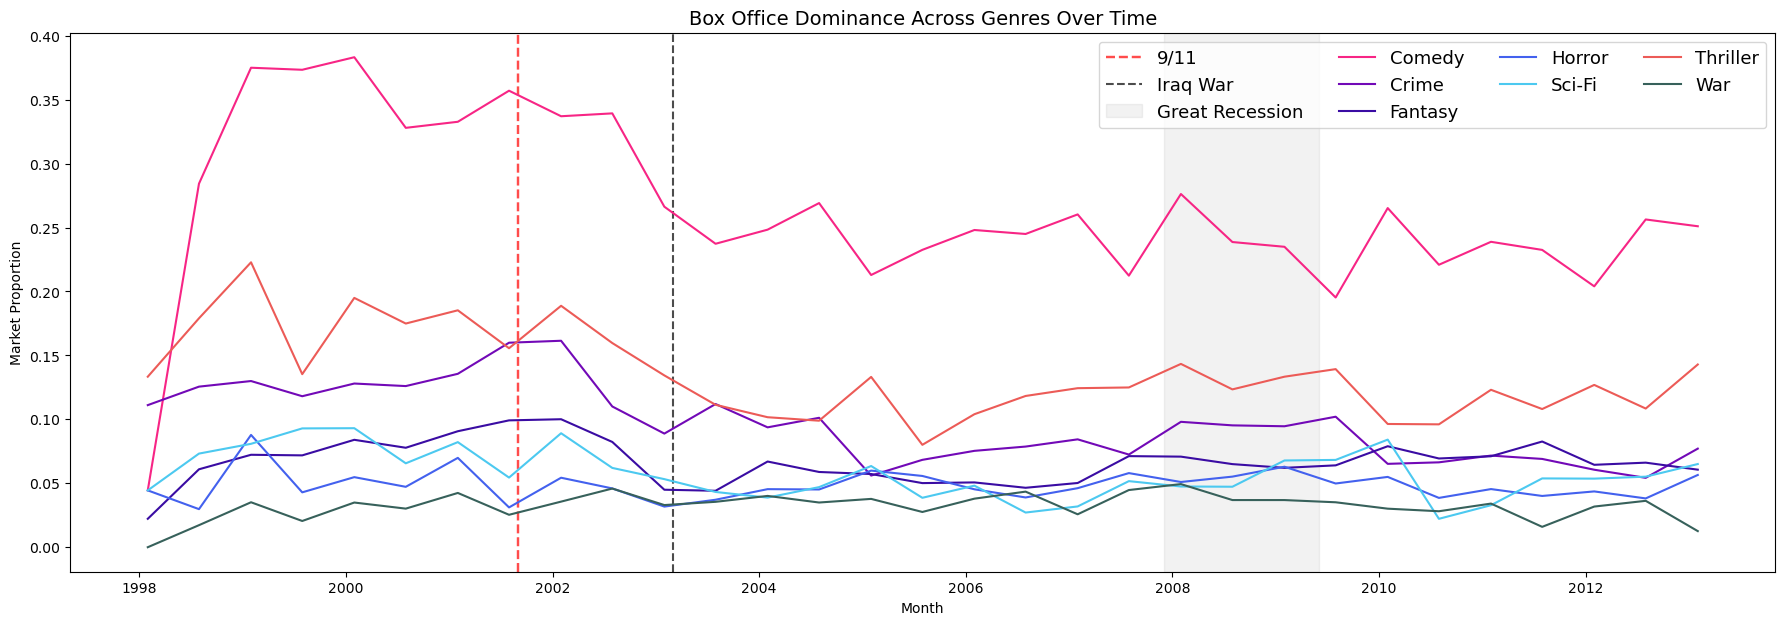

In [1295]:
plt.figure(figsize = (22, 7))

# Again, I resample the months into every 6 to smooth the volatility and see the OVERALL trend
plot_data_1 = pop_df.groupby(pop_df['Genre']).resample('6ME', on = 'Month, Year')['Proportion'].mean().reset_index() # specific plot data
colors = ["#F72585", "#7209B7", "#3A0CA3", "#4361EE", "#4CC9F0", '#EC5B57', '#37615B'] # my own palette using colors from the Web

plt.axvline(x = pd.to_datetime('2001-09-01'), # converts the September 2001 into a datetime object to correctly place the line on the axis
            color = 'red', linestyle = '--', linewidth = 1.75, alpha = 0.7, # alpha - regulates the opacity 
            label = '9/11') # the label for the legend

plt.axvline(x = pd.to_datetime('2003-03-01'), # converts the September 2001 into a datetime object to correctly place the line on the axis
            color = 'black', linestyle = '--', linewidth = 1.5, alpha = 0.7, # alpha - regulates the opacity 
            label = 'Iraq War') # the label for the legend

plt.axvspan('2007-12-01', '2009-06-01', color = 'gray', alpha = 0.10, label = 'Great Recession') # Recession shading

sns.lineplot(data = plot_data_1, # uses the newly created dataframe resampled for 6 months
             x = 'Month, Year', # dates are to be displayed on the x-axis
             y = 'Proportion', # scores are to be displayed on the y-axis
             hue = 'Genre', # groups by genre and gives different colors
             palette = colors) # using my pre-defined colors

plt.title('Box Office Dominance Across Genres Over Time', fontsize = 14) # plot title
plt.xlabel('Month') # x-axis label
plt.ylabel('Market Proportion') # y-axis label
plt.legend(fontsize = 13, loc = 'upper right', ncol = 4) # finds the best place for the legend

# saves the plot
plt.savefig('boxoffices.png')

plt.show() # outputs the plot

In [1296]:
pop_pivot = pop_df.pivot(index = 'Month, Year', # months become our horizontal pivot column
                         columns = 'Genre', # genres become our groups 
                         values = 'Proportion') # values go inside the pivot
pop_pivot.columns.name = None # helps me turn the pivot into a normal-looking pivot, making the month index into its own column

In [1297]:
pop_pivot_df = pop_pivot.reset_index() # resets index converting into a dataframe

Before proceeding to the FRED API and merging, let's change the name of the 'Month, Year' column

In [1298]:
pop_pivot_df = pop_pivot_df.rename(columns = {'Month, Year' : 'date'})

In [1299]:
pop_pivot_df

,date,Comedy,Crime,Fantasy,Horror,Sci-Fi,Thriller,War
0,1998-01-01,0.044444,0.111111,0.022222,0.044444,0.044444,0.133333,0.000000
1,1998-02-01,0.152174,0.195652,0.043478,0.065217,0.086957,0.217391,0.000000
2,1998-03-01,0.203704,0.166667,0.055556,0.037037,0.037037,0.185185,0.000000
3,1998-04-01,0.278689,0.114754,0.065574,0.016393,0.032787,0.131148,0.000000
4,1998-05-01,0.296296,0.111111,0.074074,0.000000,0.055556,0.148148,0.000000
...,...,...,...,...,...,...,...,...
175,2012-08-01,0.285000,0.055000,0.075000,0.040000,0.070000,0.105000,0.005000
176,2012-09-01,0.255000,0.075000,0.055000,0.050000,0.085000,0.135000,0.005000
177,2012-10-01,0.270000,0.090000,0.050000,0.055000,0.070000,0.165000,0.010000
178,2012-11-01,0.215000,0.085000,0.060000,0.080000,0.060000,0.160000,0.020000


### A Few Controls From the FRED

Let's add two control variables, the unemployment rate and the consumer sentiment index, from the FRED Library. <br> 
We will use them as an indicator of how the economy is doing. <br>
API Documentation: https://fred.stlouisfed.org/docs/api/fred/series_observations.html#examples

In [1302]:
api_key = '1b687f28e5349ffe291339b9f8591d8c' # our FRED API key
start_date = '1998-01-01' # start time of our analysis 
end_date = '2012-12-31' # end time

series_id_1 = 'UNRATE' # series_id for the U-3 Unemployment Rate

url1 = (
    f"https://api.stlouisfed.org/fred/series/observations?"
    f"series_id={series_id_1}&"
    f"api_key={api_key}&"
    f"observation_start={start_date}&"
    f"observation_end={end_date}&"
    f"frequency=m&"
    f"file_type=json"
)

response1 = requests.get(url1) # response from FRED
data1 = response1.json() # outputs the response to JSON format

print('Done!')

Done!


In [1303]:
# Let's examine what we've got
data1['observations'][:1] 

# Inside 'data', 'observations' is where our values lie
# 'observations' is a big list of dictionaries

[{'realtime_start': '2026-05-09',
  'realtime_end': '2026-05-09',
  'date': '1998-01-01',
  'value': '4.6'}]

In [1304]:
dates1 = [observation['date'] for observation in data1['observations']] # using a list comprehension, we first extract dates for U3 rate
dates1[0] # shows the first value

'1998-01-01'

In [1305]:
values1 = [observation['value'] for observation in data1['observations']] # using a list comprehension we then extract values for U3 rate
values1[0]

'4.6'

In [1306]:
unrate_df = pd.DataFrame({'date' : dates1, 'Unemployment Rate' : values1}) # using a dictionary to create a dataframe

In [1307]:
series_id_2 = 'UMCSENT' # series_id for the University of Michigan Consumer Sentiment Index

url2 = (
    f"https://api.stlouisfed.org/fred/series/observations?"
    f"series_id={series_id_2}&"
    f"api_key={api_key}&"
    f"observation_start={start_date}&"
    f"observation_end={end_date}&"
    f"frequency=m&"
    f"file_type=json"
)

response2 = requests.get(url2) # response from FRED
data2 = response2.json() # outputs the response to JSON format

print('Done!')

Done!


In [1308]:
dates2 = [observation['date'] for observation in data2['observations']] # using a list comprehension, we first extract dates for consumer sentiment
dates2[0] 

'1998-01-01'

In [1309]:
values2 = [observation['value'] for observation in data2['observations']] # using a list comprehension, we then extract values for consumer sentiment
values2[0]

'106.6'

In [1311]:
sent_df = pd.DataFrame({'date' : dates2, 'Consumer Sentiment': values2})

In [1367]:
len(unrate_df) # number of rows for unemployment

180

In [1368]:
 len(sent_df) # number of rows for sentiment index

180

Ready to merge!

In [1369]:
fred_df = pd.merge(unrate_df, sent_df, on = 'date', how = 'right')

In [1370]:
fred_df.isna().sum()

date                  0
Unemployment Rate     0
Consumer Sentiment    0
dtype: int64

In [1371]:
fred_df['date'] = pd.to_datetime(fred_df['date'], format = '%Y-%m-%d') # convert into datetime, to be sure

Now, as we've finished extracting our control variables, let's merge them together and have a look. Before joining, let's check the number of rows.

In [1372]:
len(fred_df) # number of rows for the fred dataframe

180

In [1373]:
len(pop_pivot_df) # number of rows for the popularities dataframe

180

In [1374]:
control_df = pd.merge(pop_pivot_df, fred_df, on = 'date', how = 'right') # right joining the two tables

In [1375]:
control_df.isna().sum() # checks for NaNs

date                  0
Comedy                0
Crime                 0
Fantasy               0
Horror                0
Sci-Fi                0
Thriller              0
War                   0
Unemployment Rate     0
Consumer Sentiment    0
dtype: int64

Before joining our initial data frame with sentiment scores, let's change the name of the control variables.

In [1376]:
control_df = control_df.rename(columns = {
    'Comedy' : 'comedypop',
    'Crime' : 'crimepop',
    'Fantasy' : 'fanpop',
    'Horror' : 'horpop',
    'Sci-Fi' : 'scipop',
    'Thriller' : 'thrillpop',
    'War' : 'warpop',
    'Unemployment Rate' : 'unrate',
    'Consumer Sentiment' : 'sent'})

control_df

,date,comedypop,crimepop,fanpop,horpop,scipop,thrillpop,warpop,unrate,sent
0,1998-01-01,0.044444,0.111111,0.022222,0.044444,0.044444,0.133333,0.000000,4.6,106.6
1,1998-02-01,0.152174,0.195652,0.043478,0.065217,0.086957,0.217391,0.000000,4.6,110.4
2,1998-03-01,0.203704,0.166667,0.055556,0.037037,0.037037,0.185185,0.000000,4.7,106.5
3,1998-04-01,0.278689,0.114754,0.065574,0.016393,0.032787,0.131148,0.000000,4.3,108.7
4,1998-05-01,0.296296,0.111111,0.074074,0.000000,0.055556,0.148148,0.000000,4.4,106.5
...,...,...,...,...,...,...,...,...,...,...
175,2012-08-01,0.285000,0.055000,0.075000,0.040000,0.070000,0.105000,0.005000,8.1,74.3
176,2012-09-01,0.255000,0.075000,0.055000,0.050000,0.085000,0.135000,0.005000,7.8,78.3
177,2012-10-01,0.270000,0.090000,0.050000,0.055000,0.070000,0.165000,0.010000,7.8,82.6
178,2012-11-01,0.215000,0.085000,0.060000,0.080000,0.060000,0.160000,0.020000,7.7,82.7


We create our final dataframe - time series, merging 'data_pivot_df' and 'control_df'

In [1377]:
len(data_pivot_df) # rows in df: scores by genre

174

In [1378]:
len(control_df) # rows in df: popularities by genre + fred variables

180

In [1379]:
time_series_df = pd.merge(data_pivot_df, control_df, on = 'date', how = 'right') # the join would return 6 NaN values
len(time_series_df) # checks the number of rows before dropping

180

In [1380]:
time_series_df[:10]

,date,Crime Thriller,Fantasy/Sci-Fi,Horror,Romcom,War,Overall,comedypop,crimepop,fanpop,horpop,scipop,thrillpop,warpop,unrate,sent
0,1998-01-01,NaN,NaN,NaN,NaN,NaN,NaN,0.044444,0.111111,0.022222,0.044444,0.044444,0.133333,0.000000,4.6,106.6
1,1998-02-01,NaN,NaN,NaN,NaN,NaN,NaN,0.152174,0.195652,0.043478,0.065217,0.086957,0.217391,0.000000,4.6,110.4
2,1998-03-01,NaN,NaN,NaN,NaN,NaN,NaN,0.203704,0.166667,0.055556,0.037037,0.037037,0.185185,0.000000,4.7,106.5
3,1998-04-01,NaN,NaN,NaN,NaN,NaN,NaN,0.278689,0.114754,0.065574,0.016393,0.032787,0.131148,0.000000,4.3,108.7
4,1998-05-01,NaN,NaN,NaN,NaN,NaN,NaN,0.296296,0.111111,0.074074,0.000000,0.055556,0.148148,0.000000,4.4,106.5
5,1998-06-01,NaN,NaN,NaN,NaN,NaN,NaN,0.434783,0.065217,0.086957,0.000000,0.086957,0.152174,0.043478,4.5,105.6
6,1998-07-01,0.344967,0.798360,0.641500,0.797482,0.237822,0.564026,0.340000,0.100000,0.040000,0.060000,0.140000,0.240000,0.060000,4.5,105.2
7,1998-08-01,0.647088,0.575106,-0.024716,0.704674,0.113489,0.403128,0.413043,0.108696,0.043478,0.086957,0.173913,0.282609,0.043478,4.5,104.4
8,1998-09-01,0.556528,0.569964,0.058896,0.679907,0.218633,0.416786,0.333333,0.185185,0.055556,0.074074,0.129630,0.277778,0.037037,4.6,100.9
9,1998-10-01,0.485180,0.556775,0.005405,0.719048,0.283291,0.409940,0.314815,0.166667,0.055556,0.111111,0.074074,0.166667,0.018519,4.5,97.4


#### Because the reviews on IMDb started in June 1998, that will be our initial point. We'll drop the first six rows with NaN values.

In [1381]:
time_series_df = time_series_df.dropna().reset_index(drop = True) # drops the 6 rows with NaN values 

len(time_series_df) # checks the number of rows after dropping the first six months
# Should be 174

174

Let's rename the other columns for easier regression analysis later

In [1382]:
time_series_df = time_series_df.rename(columns = {
    'Crime Thriller' : 'crimescore',
    'Fantasy/Sci-Fi' : 'fanscore',
    'Horror' : 'horscore',
    'Romcom' : 'comscore',
    'War' : 'warscore',
    'Overall' : 'genscore' # this will be our average sentiment score across all genres
})

At last, we'll add our 9/11 dummy variable.

In [1383]:
post_911 = np.where(time_series_df['date'] >= pd.to_datetime('2001-09-01'), 1, 0) # assigns '1' to September 2001 and after, '0' to all else
time_series_df.insert(1, 'post_911', post_911) # inserts the column right after the date, at index = 1

time_series_df[36:41] # looks in-between July and November 2001 

,date,post_911,crimescore,fanscore,horscore,comscore,warscore,genscore,comedypop,crimepop,fanpop,horpop,scipop,thrillpop,warpop,unrate,sent
36,2001-07-01,0,0.437751,0.675328,0.100486,0.831635,0.318834,0.472807,0.300000,0.144444,0.088889,0.011111,0.077778,0.144444,0.033333,4.6,92.4
37,2001-08-01,0,0.498260,0.584727,0.066034,0.844540,0.383173,0.475347,0.351064,0.170213,0.085106,0.053191,0.117021,0.180851,0.031915,4.9,91.5
38,2001-09-01,1,0.454746,0.512084,0.194596,0.794682,0.418852,0.474992,0.347826,0.173913,0.097826,0.054348,0.119565,0.217391,0.021739,5.0,81.8
39,2001-10-01,1,0.392263,0.611631,0.029544,0.767145,0.519914,0.464100,0.358491,0.188679,0.103774,0.075472,0.094340,0.188679,0.028302,5.3,82.7
40,2001-11-01,1,0.434176,0.542013,0.085653,0.880630,0.261748,0.440844,0.326531,0.173469,0.112245,0.071429,0.071429,0.214286,0.030612,5.5,83.9


Here is the final version of our time series dataframe - prepared for analysis:

In [1384]:
time_series_df

,date,post_911,crimescore,fanscore,horscore,comscore,warscore,genscore,comedypop,crimepop,fanpop,horpop,scipop,thrillpop,warpop,unrate,sent
0,1998-07-01,0,0.344967,0.798360,0.641500,0.797482,0.237822,0.564026,0.340000,0.100000,0.040000,0.060000,0.140000,0.240000,0.060000,4.5,105.2
1,1998-08-01,0,0.647088,0.575106,-0.024716,0.704674,0.113489,0.403128,0.413043,0.108696,0.043478,0.086957,0.173913,0.282609,0.043478,4.5,104.4
2,1998-09-01,0,0.556528,0.569964,0.058896,0.679907,0.218633,0.416786,0.333333,0.185185,0.055556,0.074074,0.129630,0.277778,0.037037,4.6,100.9
3,1998-10-01,0,0.485180,0.556775,0.005405,0.719048,0.283291,0.409940,0.314815,0.166667,0.055556,0.111111,0.074074,0.166667,0.018519,4.5,97.4
4,1998-11-01,0,0.564890,0.669245,0.184848,0.652414,0.196182,0.453516,0.400000,0.140000,0.100000,0.080000,0.040000,0.200000,0.040000,4.4,102.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,2012-08-01,1,0.579388,0.777121,0.067476,0.766636,0.483531,0.534830,0.285000,0.055000,0.075000,0.040000,0.070000,0.105000,0.005000,8.1,74.3
170,2012-09-01,1,0.324702,0.614681,-0.028526,0.786440,0.489475,0.437355,0.255000,0.075000,0.055000,0.050000,0.085000,0.135000,0.005000,7.8,78.3
171,2012-10-01,1,0.593422,0.684200,0.073558,0.959444,0.592528,0.580630,0.270000,0.090000,0.050000,0.055000,0.070000,0.165000,0.010000,7.8,82.6
172,2012-11-01,1,0.302100,0.576313,0.101517,0.924958,0.410578,0.463093,0.215000,0.085000,0.060000,0.080000,0.060000,0.160000,0.020000,7.7,82.7


In [1385]:
time_series_df.to_csv('time_series_data.csv', index = False) # not to include index as the first column